In [1]:
import meep as mp
import meep.adjoint as mpa
import autograd.numpy as npa
import numpy as np
import nlopt
from matplotlib import pyplot as plt
from icecream import ic

from gradoptest import get_opt
from utils import normalise, mirror_upper_y_half, smooth_image


In [2]:
opt, sim_args = get_opt()

Nx = sim_args['Nx']
Ny = sim_args['Ny']
filter_radius = sim_args['filter_radius']
design_region_width = sim_args['design_region_width']
design_region_height = sim_args['design_region_height']
design_region_resolution = sim_args['design_region_resolution']
eta_i = sim_args['eta_i']


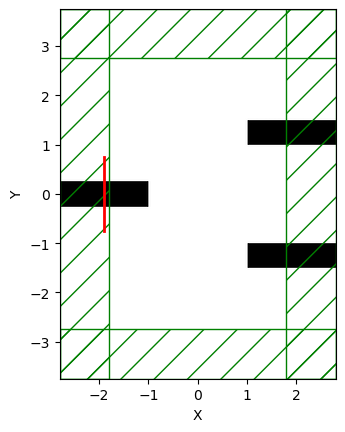

In [3]:
opt.plot2D()

In [4]:
def mapping(x,eta,beta):
    x = (npa.fliplr(x.reshape(Nx,Ny)) + x.reshape(Nx,Ny))/2 # up-down symmetry
    
    # filter
    filtered_field = mpa.conic_filter(x,
        filter_radius,design_region_width,design_region_height,design_region_resolution)
    
    # projection
    projected_field = mpa.tanh_projection(filtered_field,beta,eta)
    
    # interpolate to actual materials
    return projected_field.flatten()

In [ ]:
x0 = 0.5*np.ones((Nx,Ny))
f0, g0 = opt([mapping(x0,0.5,2)])

Starting forward run...
Starting adjoint run...


(18281, 5)


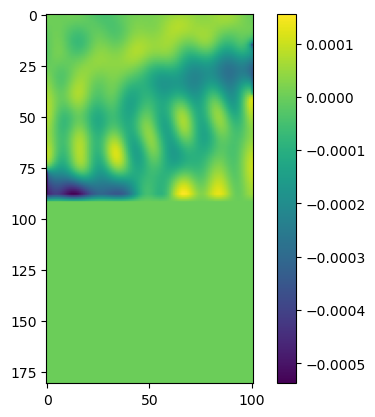

In [ ]:
plt.figure()
print(g0.shape)
plt.imshow(np.rot90(g0[:,0].reshape(Nx,Ny)))
plt.colorbar()

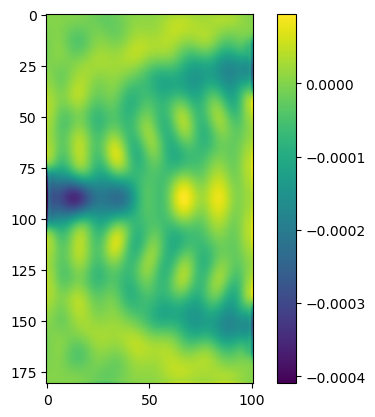

In [ ]:
from autograd import tensor_jacobian_product
backprop_gradient = tensor_jacobian_product(mapping,0)(x0,0.5,2,g0[:,0])
plt.imshow(np.rot90(backprop_gradient.reshape(Nx,Ny)))
plt.colorbar()

# Optimizer setup

In [ ]:
def f(v, gradient, cur_beta):
    print("Current iteration: {}".format(cur_iter[0]+1))
    
    f0, dJ_du = opt([mapping(v,eta_i,cur_beta)])
    
    plt.subplot(1,2,1)
    ax = plt.gca()
    opt.plot2D(False,ax=ax,plot_sources_flag=False,plot_monitors_flag=False,plot_boundaries_flag=False)
    ax.axis('off')

    
    if gradient.size > 0:
        gradient[:] = tensor_jacobian_product(mapping,0)(v,eta_i,cur_beta,np.sum(dJ_du,axis=1))*10
    
    evaluation_history.append(np.max(np.real(f0)))
    cur_iter[0] = cur_iter[0] + 1

    # Debugging bits
    #------------------
    ic(f0)
    ic(gradient.min(), gradient.max(), gradient.mean())
    plt.subplot(1,2,2)
    plt.imshow(np.rot90(gradient.reshape(Nx,Ny)))
    plt.colorbar()
    plt.axis('off')
    plt.show()
    #------------------
    
    return np.real(f0)

current beta:  4
Current iteration: 1
Starting forward run...
Starting adjoint run...
Calculating gradient...


ic| f0: 0.0749621683289561
ic| gradient.min(): -0.006054843219671039
    gradient.max(): 0.0037443285820568445
    gradient.mean(): -0.0006432552393195759


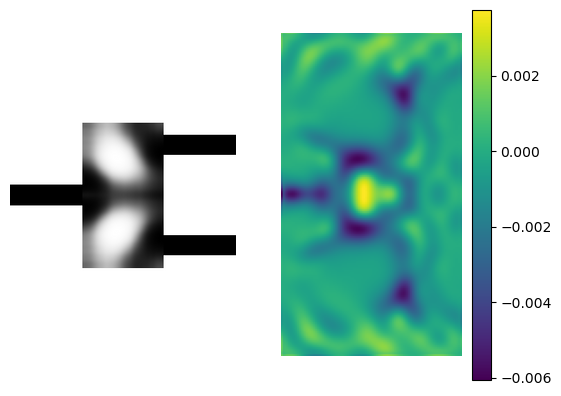

Current iteration: 2
Starting forward run...
Starting adjoint run...


In [ ]:
evaluation_history = []
cur_iter = [0]
algorithm = nlopt.LD_MMA
n = Nx * Ny # number of parameters

# Initial guess
x = np.random.rand(Nx, Ny)
x = normalise(mirror_upper_y_half(smooth_image(x))).flatten()

# lower and upper bounds
lb = 0
ub = 1

cur_beta = 4
beta_scale = 2
num_betas = 6
update_factor = 12
for iters in range(num_betas):
    print("current beta: ",cur_beta)
    
    solver = nlopt.opt(algorithm, n)
    solver.set_lower_bounds(lb)
    solver.set_upper_bounds(ub)
    solver.set_max_objective(lambda a,g: f(a,g,cur_beta))
    solver.set_maxeval(update_factor)
    x[:] = solver.optimize(x)
    cur_beta = cur_beta*beta_scale

## Final device evaluation

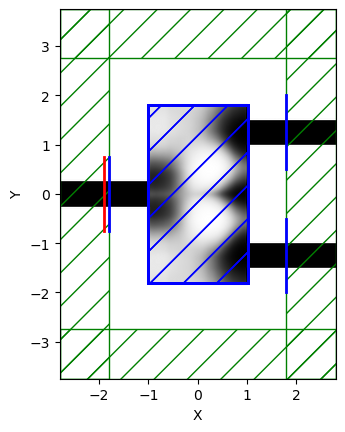

In [ ]:
opt.plot2D(True)

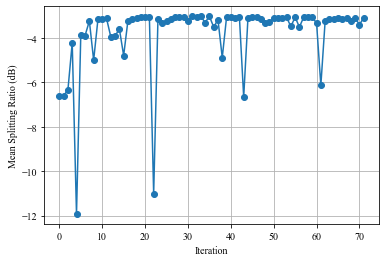

In [ ]:
plt.figure()
plt.plot(10*np.log10(0.5*np.array(evaluation_history)),'o-')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('Mean Splitting Ratio (dB)')
plt.show()

In [ ]:
f0, dJ_du = opt([mapping(x,eta_i,cur_beta)],need_gradient = False)
frequencies = opt.frequencies
source_coef, top_coef, bottom_ceof = opt.get_objective_arguments()

top_profile = np.abs(top_coef/source_coef) ** 2
bottom_profile = np.abs(bottom_ceof/source_coef) ** 2

Starting forward run...


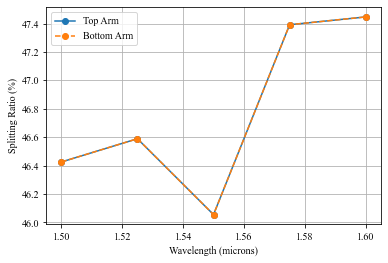

In [ ]:
plt.figure()
plt.plot(1/frequencies,top_profile*100,'-o' ,label = 'Top Arm')
plt.plot(1/frequencies,bottom_profile*100,'--o',label = 'Bottom Arm')
plt.legend()
plt.grid(True)
plt.xlabel('Wavelength (microns)')
plt.ylabel('Splitting Ratio (%)')
#plt.ylim(46.5,50)
plt.show()